# Missing values and winnowing: two C5.0 mechanisms up close

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daviddiazsolis/c50py/blob/main/examples/notebooks/05_missing_values_and_winnowing.ipynb)

Two things real business tables always have: gaps, and more columns than the problem needs. C5.0
has a built-in answer to each. This notebook explains how they work, measures what they buy, and
says where they fall short.

1. **Missing values.** C5.0 learns and predicts with incomplete rows, without imputation.
2. **Winnowing.** C5.0 can discard columns that do not help before it grows the final tree.

In [1]:
# Colab / a fresh environment: install c50py (0.5 or later)
import importlib, subprocess, sys
try:
    import c50py
    assert tuple(int(v) for v in c50py.__version__.split(".")[:2]) >= (0, 5)
except (ImportError, AssertionError):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "c50py>=0.5.0"], check=True)
    import c50py
    importlib.reload(c50py)
print("c50py", c50py.__version__)

c50py 0.5.0


In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from c50py import C5Classifier

def load(data_id):
    d = fetch_openml(data_id=data_id, as_frame=True, parser="pandas")
    X = d.data.copy()
    for c in X.columns:
        if str(X[c].dtype) in ("object", "str", "string", "bool"):
            X[c] = X[c].astype("category")
    return X, d.target.astype(str).to_numpy()

X, y = load(40701)          # churn: 5,000 telecom customers
cv = StratifiedKFold(5, shuffle=True, random_state=0)

## Part 1. Missing values

### The idea

Imputation answers the question "what value would this customer probably have had?" and then
treats the guess as if it were known. C5.0 (following C4.5, Quinlan 1993) answers a different
question: "given that we do not know, what are the possible paths through the tree, and how likely
is each?". It does two things.

**When choosing a split**, a column with many gaps is penalised: its gain is computed on the cases
where it is known and then scaled down by the share of cases where it is known. This is the
*C4.5 gain with unknown values*:

$$\text{Gain}(A) = \frac{n_{\text{known}}}{n}\,\Big(\text{Info}(S_{\text{known}}) - \text{Info}_A(S_{\text{known}})\Big)$$

* $A$: the candidate test (a column and a threshold, or a column and a grouping of its categories).
* $n$: the total weight of the training cases at the node; $n_{\text{known}}$: the weight of those
  whose value of the column is known.
* $S_{\text{known}}$: the cases at the node with the value known.
* $\text{Info}(S)$: the entropy of the class in $S$, in bits: $-\sum_k p_k \log_2 p_k$, where
  $p_k$ is the share of class $k$.
* $\text{Info}_A(S)$: the average entropy of the class in the branches of $A$, each branch weighted
  by its share of cases.

In words: a column that is informative where it is known, but known for only half of the customers,
gets half the credit. A gain of 0.10 bits on a column that is 80% complete counts as 0.08.

**When a case reaches a test on a column it does not have**, it is split into pieces that go down
every branch, with weights proportional to the share of training cases that went down each branch.
A customer whose number of daytime minutes is missing, at a node where 70% of the training customers
went left, continues as 0.7 of a customer on the left and 0.3 on the right. The prediction is the
weighted mix of the leaves the pieces reach. During training the same happens, which is why some
`samples` counts in the plotted trees have decimals.

### An example, one customer

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
tree = C5Classifier().fit(X_tr, y_tr)
root = tree.feature_names_[tree.tree_.feature_index]
print("first test of the tree is on:", root)

one = X_te.iloc[[0]].copy()
blank = one.copy(); blank[root] = np.nan
print("P(churn) with the value known:  ", tree.predict_proba(one)[0, list(tree.classes_).index("1")].round(3))
print("P(churn) with the value missing:", tree.predict_proba(blank)[0, list(tree.classes_).index("1")].round(3))

first test of the tree is on: total_day_minutes
P(churn) with the value known:   0.065
P(churn) with the value missing: 0.028


With the value missing, the probability is a mix of what the tree would say on each side of the
root, weighted by how common each side is. The rule shown by `apply_rules` for such a row is the
one on the most common path (a single rule has to be chosen to display it), while the probability
uses all paths.

### How much accuracy does it keep?

We blank out a growing share of the values at random, in both the training and the test folds, and
compare four ways of coping, with 5-fold cross-validation:

* c50py as it is (fractional cases);
* c50py after filling gaps with the median (numbers) or the most frequent value (categories),
  computed on the training fold;
* `HistGradientBoostingClassifier`, which also accepts gaps: at each split it learns on which side
  to send them;
* HGB after the same filling.

In [4]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone

class Filled(ClassifierMixin, BaseEstimator):
    """Fill gaps with the training median / most frequent value, then fit the model."""
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        self.fill_ = {c: (X[c].mode()[0] if str(X[c].dtype) == "category" else X[c].median()) for c in X.columns}
        self.model_ = clone(self.model).fit(X.fillna(self.fill_), y)
        self.classes_ = self.model_.classes_
        return self
    def predict(self, X):
        return self.model_.predict(X.fillna(self.fill_))

def blank_out(X, rate, seed=0):
    rng = np.random.default_rng(seed)
    Xm = X.copy()
    for c in Xm.columns:
        Xm.loc[rng.random(len(Xm)) < rate, c] = np.nan
    return Xm

hgb = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0)
contenders = {"c50py, fractional cases": C5Classifier(),
              "c50py, filled": Filled(C5Classifier()),
              "HGB, native gaps": hgb,
              "HGB, filled": Filled(hgb)}
rows = []
for rate in [0, 0.1, 0.2, 0.3, 0.4]:
    Xm = blank_out(X, rate)
    for label, model in contenders.items():
        rows.append(dict(missing=rate, model=label, accuracy=cross_val_score(model, Xm, y, cv=cv).mean()))
mcar = pd.DataFrame(rows).pivot(index="missing", columns="model", values="accuracy")
mcar.round(3)

model,"HGB, filled","HGB, native gaps","c50py, filled","c50py, fractional cases"
missing,,,,
0.0,0.960,0.960,0.944,0.944
0.1,0.940,0.940,0.927,0.926
0.2,0.928,0.925,0.914,0.906
0.3,0.916,0.914,0.903,0.884
0.4,0.899,0.899,0.893,0.864


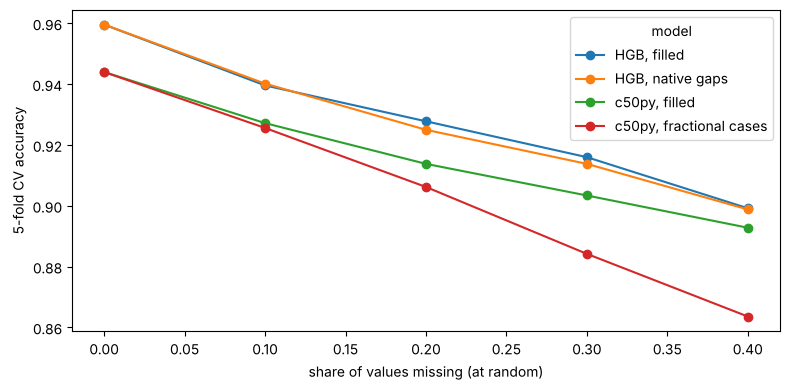

In [5]:
ax = mcar.plot(marker="o", figsize=(8, 4))
ax.set_xlabel("share of values missing (at random)"); ax.set_ylabel("5-fold CV accuracy")
plt.tight_layout(); plt.show()

What to take from this experiment (gaps at random, the textbook case):

* All methods lose accuracy as the gaps grow; nothing recovers information that is not there.
* With few gaps (10%), c50py's fractional cases and simple filling give the same accuracy.
* **With many gaps, simple filling is better here**: about one point at 20% and three points at
  40%. When every column of almost every row has gaps, each case is split into many small pieces
  and the leaves average over many paths, which blurs the predictions. Filling makes a cruder but
  sharper guess, and on these data the guess is good enough.
* HGB is a couple of points more accurate than the single tree throughout, as notebook 03 found,
  and is barely affected by the way gaps are handled.

So the honest advice: fractional cases are a sound default that needs no preprocessing and gives
probabilities that admit a value was unknown; when a large share of the data is missing, compare
it with filling by cross-validation (the `Filled` wrapper above is all it takes) and keep whichever
is better.

### When the gap itself is information

In business data, values are rarely missing at random. A customer who never filled in their income,
a company with no rating: the fact that the value is missing often says something about the target.
C5.0's mechanism does not use that: it treats a gap as "could be anything, in the usual
proportions". HGB, which learns where to send gaps, can use it.

We simulate it: the number of customer-service calls is blanked out, but mostly for customers who
did not churn (say, the field is only recorded when a complaint is escalated).

In [6]:
calls = "number_customer_service_calls"
rng = np.random.default_rng(1)
Xi = X.copy()
Xi.loc[(y == "0") & (rng.random(len(y)) < 0.6), calls] = np.nan
print("share missing among stayers:", Xi[calls][y == "0"].isna().mean().round(2),
      " among churners:", Xi[calls][y == "1"].isna().mean().round(2))

Xi_flag = Xi.copy()
Xi_flag["calls_missing"] = pd.Categorical(np.where(Xi[calls].isna(), "yes", "no"))

for label, model, data in [("c50py, fractional cases", C5Classifier(), Xi),
                           ("c50py + 'is missing' column", C5Classifier(), Xi_flag),
                           ("HGB, native gaps", hgb, Xi)]:
    print(f"{label:30s} {cross_val_score(model, data, y, cv=cv).mean():.3f}")

share missing among stayers: 0.6  among churners: 0.0


c50py, fractional cases        0.935


c50py + 'is missing' column    0.955


HGB, native gaps               0.965


The remedy is simple and keeps the model readable: when there is a reason to think the gap is
informative, add a column that says so (`calls_missing = yes/no`), or, for a categorical column,
make "missing" one more category. The tree can then use the gap in a rule such as
`calls_missing IN {yes} AND ...`, and the rule says it in plain words.

## Part 2. Winnowing

### The idea

Business tables accumulate columns: every system adds a few. Most of them are irrelevant for a
given question, and a tree that can choose among many columns will, by chance, find some that look
useful on the training data. Winnowing (C5.0's name for its feature selection) screens the columns
before the final tree is grown:

1. Split the training cases into two halves with the same class frequencies.
2. Grow a trial tree on the first half. Columns it never uses are candidates for removal.
3. For each column the pruned trial tree does use, measure its errors on the second half with that
   column blanked out (treated as missing). If the errors **go down**, the column was hurting: it
   is also a candidate.
4. If removing the harmful columns makes a new trial tree worse on the second half, keep them.
5. Grow the final tree on all the cases, without the removed columns.

It is a quick, honest check: a column has to help a tree on cases it did not learn from. It is
not exhaustive: a column that matters only together with another may be dropped.

### An example: 20 useless columns added to the churn data

In [7]:
rng = np.random.default_rng(2)
noise = pd.DataFrame({f"noise_num_{i}": rng.normal(size=len(X)) for i in range(10)})
for i in range(10):
    noise[f"noise_cat_{i}"] = pd.Categorical(rng.choice(list("abcdefgh"), len(X)))
X_noisy = pd.concat([X.reset_index(drop=True), noise], axis=1)

for label, model in [("no winnowing", C5Classifier()), ("winnow=True", C5Classifier(winnow=True))]:
    acc = cross_val_score(model, X_noisy, y, cv=cv).mean()
    fitted = model.fit(X_noisy, y)
    used = {fitted.feature_names_[j] for j in fitted._tree_features(fitted.tree_)}
    print(f"{label:13s} CV accuracy {acc:.3f}   leaves {len(fitted.export_rules()):3d}   "
          f"columns used {len(used):2d}   noise columns used {sum(c.startswith('noise') for c in used)}")

no winnowing  CV accuracy 0.940   leaves  86   columns used 28   noise columns used 13


winnow=True   CV accuracy 0.943   leaves  61   columns used 13   noise columns used 3


In [8]:
w = C5Classifier(winnow=True).fit(X_noisy, y)
print(f"winnowing dropped {len(w.winnowed_features_)} of {X_noisy.shape[1]} columns:")
print(sorted(w.winnowed_features_))

winnowing dropped 20 of 40 columns:
['account_length', 'noise_cat_0', 'noise_cat_5', 'noise_cat_7', 'noise_num_0', 'noise_num_2', 'noise_num_3', 'noise_num_4', 'noise_num_5', 'noise_num_6', 'noise_num_7', 'noise_num_8', 'number_vmail_messages', 'phone_number', 'state', 'total_day_charge', 'total_eve_calls', 'total_eve_minutes', 'total_intl_charge', 'total_night_calls']


How to read it: without winnowing the tree uses 13 of the 20 noise columns, which make it larger
(86 leaves) and add rules that mean nothing. With winnowing, 17 noise columns are gone before the
final tree is grown, the tree has 61 leaves and is as accurate. Notice also which real columns were
dropped: `total_day_charge` and `total_intl_charge` are the minutes times a tariff, so they repeat
what the minutes already say, and `phone_number` and `state` carry no signal. The screen is not
perfect (three noise columns survive, by chance they looked useful on both halves), which is why
it is a first filter and not a substitute for judgement.

On data where every column is relevant winnowing changes little, and it is off by default for that
reason. It is most useful at the start of a project, when it is not yet clear which of the many
available columns matter, and its list of dropped columns is a useful output in itself: it tells
the business which data it does not need to collect for this decision.